In [1]:
import sys
import os
from datetime import datetime
from collections import OrderedDict

import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt
from matplotlib import colormaps

from tqdm import tqdm
import scipy

import wandb

from torchvision.models import VGG


import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets.folder import default_loader

from zennit.attribution import Gradient

from xaikd.utils import metrics
from xaikd import models, datasets, utils
from xaikd import attributors
from xaikd import explainers

from sklearn.metrics import ConfusionMatrixDisplay

/home/pat/projects/xai-kd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WANDB_API = wandb.Api()

In [3]:
# os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
WANDB_PROJECT = "xaikd-s41-why-heatmaps-are-bad"

GROUP = "basis-identity-attn-with-power"
TOTAL_SEEDS = 3

# Data Reader

In [5]:
def read_data(
    teacher, student,
    dataset,
    dataset_variant,
    policy,
    training_size=1.0,
    verbose=False,
):
    
    
    additional_query = {}

    if dataset_variant == "spurious-threespurious--1.0":
        if policy != "ce_only":
            additional_query = {"config.default-lambda-layer-config": "imagenet-spurious"}
    
    

    if policy == "ce_only":
        policy = "nothing"
        lambda_task = 1.0
        lambda_kd = 0.0
    else:
        lambda_task = 0.0
        lambda_kd = 1.0
    
    if policy == "kd_only":
        policy = "nothing"
    

    
    
    runs = WANDB_API.runs(
        WANDB_PROJECT,
        {
        "$and": [
            {"group": {"$in": [GROUP]}},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": dataset},
            {"config.dataset-variant": dataset_variant},
            {"config.training_size": training_size},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
#             additional_query
        ]
        }
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        
        best_val_acc = run.summary["arr_metrics"]["val_acc"][-1]
    
        best_train_acc = run.summary["arr_metrics"]["train_acc"][-1]


        rows.append(
            dict(
                val_acc=best_val_acc, 
                train_acc=best_train_acc,
                teacher_acc=run.summary["teacher_acc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    np.testing.assert_allclose(
        df.shape[0],
        TOTAL_SEEDS
    )

    df = df.sort_values(by="val_acc", ascending=False)

    
    return df
  
_df = read_data(
    teacher="imagenet-resnet18-tv",
    student="student-32-24-16-8",
    policy="basis-identity:prca-sortabs-corrected-sign--uncentered",
    
    dataset="imagenet-butterfly",
    dataset_variant="spurious-threespurious--1.0",
    training_size=1.0,

    verbose=True,
)
_df

we have 3 runs


,val_acc,train_acc,teacher_acc,run_id,lr,seed,epochs,layers,policy,dataset,...,training-size,training_size,dataset-variant,last_layer_policy,enable_checkpointing,wandb-experiment-group,wandb_experiment_group,parameter_partition_mode,finetuning_with_layer_loss,default_lambda_layer_config
1,0.826667,0.886105,0.923333,v0u1ziwr,0.0005,2,100,"layer3:layer3,layer4:layer4",basis-identity:prca-sortabs-corrected-sign--un...,imagenet-butterfly,...,1,1,spurious-threespurious--1.0,kd,False,basis-identity-attn-with-power,basis-identity-attn-with-power,@0,True,None
0,0.800000,0.890108,0.923333,td9bn28h,0.0005,3,100,"layer3:layer3,layer4:layer4",basis-identity:prca-sortabs-corrected-sign--un...,imagenet-butterfly,...,1,1,spurious-threespurious--1.0,kd,False,basis-identity-attn-with-power,basis-identity-attn-with-power,@0,True,None
2,0.780000,0.874871,0.923333,ssirielw,0.0005,1,100,"layer3:layer3,layer4:layer4",basis-identity:prca-sortabs-corrected-sign--un...,imagenet-butterfly,...,1,1,spurious-threespurious--1.0,kd,False,basis-identity-attn-with-power,basis-identity-attn-with-power,@0,True,None


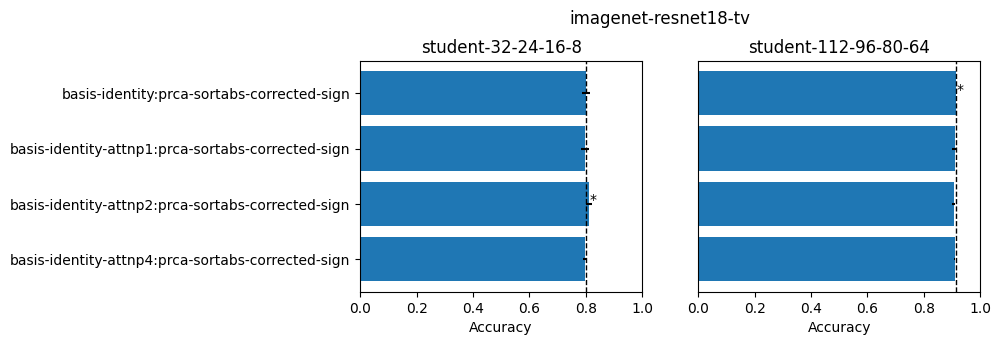

In [32]:
def viz(teacher, arr_students, arr_policies):
    
    dataset = "imagenet-butterfly"
    dataset_variant = "spurious-threespurious--1.0"
    ncols = len(arr_students)
    npolicies = len(arr_policies)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(teacher, y=1.05)
    ticks = np.arange(npolicies)
    for six, student in enumerate(arr_students):
        plt.subplot(1, ncols, six+1)
        plt.gca().invert_yaxis()
        plt.title(student)
        stats = np.zeros((npolicies, 2))
        for pix, policy in enumerate(arr_policies):
            df = read_data(
                teacher=teacher,
                student=student,
                policy=f"{policy}--uncentered",
                dataset=dataset,
                dataset_variant=dataset_variant,
                training_size=1.0,
                verbose=False,
            )
            values = df["val_acc"]
            stats[pix, :] = np.mean(values), scipy.stats.sem(values)
    
            
        plt.barh(ticks, stats[:, 0], xerr=stats[:, 1])
        plt.axvline(stats[0, 0], ls="--", lw=1, color="k")
        imax = np.argmax(stats[:, 0])
        
        plt.text(stats[imax, 0], imax, "*")
        if six == 0:
            plt.yticks(ticks, arr_policies)
        else:
            plt.yticks([])
        plt.xlim([0, 1])
        plt.xlabel("Accuracy")

viz(
    teacher="imagenet-resnet18-tv",
    arr_students=["student-32-24-16-8", "student-112-96-80-64"],
    arr_policies=[
        "basis-identity:prca-sortabs-corrected-sign",
        "basis-identity-attnp1:prca-sortabs-corrected-sign",
        "basis-identity-attnp2:prca-sortabs-corrected-sign",
        "basis-identity-attnp4:prca-sortabs-corrected-sign",
    ]
)    

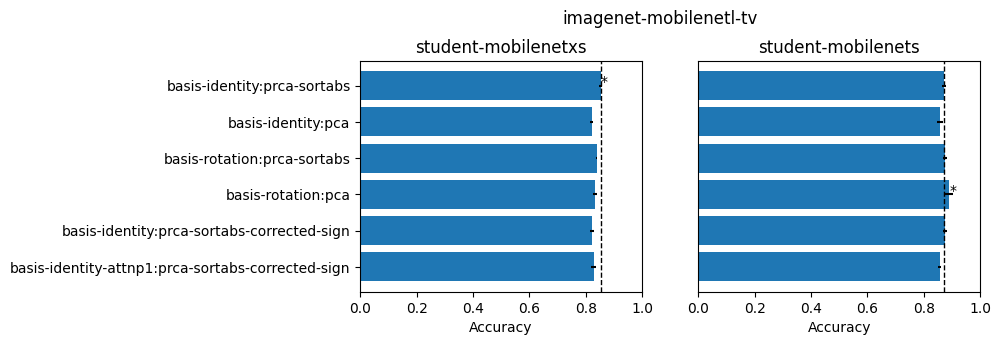

In [39]:
viz(
    teacher="imagenet-mobilenetl-tv",
    arr_students=["student-mobilenetxs", "student-mobilenets"],
    arr_policies=[
        "basis-identity:prca-sortabs",
        "basis-identity:pca",
        
        "basis-rotation:prca-sortabs",
        "basis-rotation:pca",

        "basis-identity:prca-sortabs-corrected-sign",

        "basis-identity-attnp1:prca-sortabs-corrected-sign",
    ]
)    

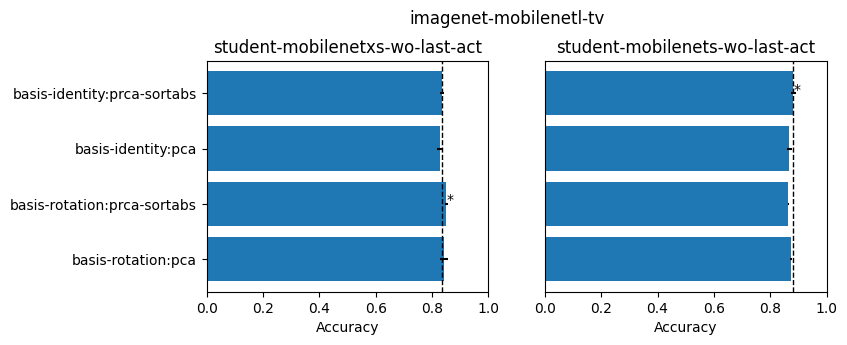

In [41]:
viz(
    teacher="imagenet-mobilenetl-tv",
    arr_students=["student-mobilenetxs-wo-last-act", "student-mobilenets-wo-last-act"],
    arr_policies=[
        "basis-identity:prca-sortabs",
        "basis-identity:pca",
        
        "basis-rotation:prca-sortabs",
        "basis-rotation:pca",

#         "basis-identity:prca-sortabs-corrected-sign",

#         "basis-identity-attnp1:prca-sortabs-corrected-sign",
    ]
)    

# Vis: Comparing Students  with and without last act

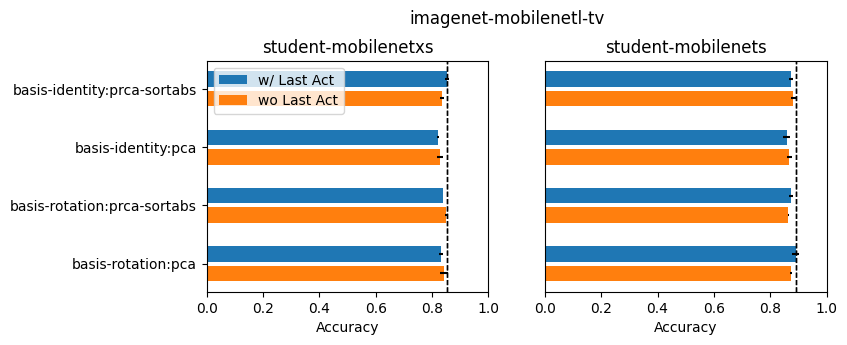

In [49]:
def student_suffix_alias(suffix):
    if suffix == "":
        return "w/ Last Act"
    elif suffix == "-wo-last-act":
        return "wo Last Act"
    else:
        raise
        
def viz_student_comparision(teacher, arr_students, arr_policies):
    
    dataset = "imagenet-butterfly"
    dataset_variant = "spurious-threespurious--1.0"
    ncols = len(arr_students)
    npolicies = len(arr_policies)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(teacher, y=1.05)
    ticks = np.arange(npolicies)
    for six, student in enumerate(arr_students):
        plt.subplot(1, ncols, six+1)
        plt.gca().invert_yaxis()
        plt.title(student)
        
        vmax = -1 
        for fix, student_suffix in enumerate(["", "-wo-last-act"]):
            stats = np.zeros((npolicies, 2))

            for pix, policy in enumerate(arr_policies):
                df = read_data(
                    teacher=teacher,
                    student=f"{student}{student_suffix}",
                    policy=f"{policy}--uncentered",
                    dataset=dataset,
                    dataset_variant=dataset_variant,
                    training_size=1.0,
                    verbose=False,
                )
                values = df["val_acc"]
                stats[pix, :] = np.mean(values), scipy.stats.sem(values)
                
            if np.max(stats[:, 0]) > vmax:
                vmax = np.max(stats[:, 0])
                


            plt.barh(ticks*3 +fix, stats[:, 0], xerr=stats[:, 1], label=student_suffix_alias(student_suffix))
            plt.axvline(vmax, ls="--", lw=1, color="k")
    
        if six == 0:
            plt.yticks(ticks*3 + 0.5, arr_policies)
        else:
            plt.yticks([])
        plt.xlim([0, 1])
        plt.xlabel("Accuracy")
        if six == 0:
            plt.legend()

viz_student_comparision(
    teacher="imagenet-mobilenetl-tv",
    arr_students=["student-mobilenetxs", "student-mobilenets"],
    arr_policies=[
        "basis-identity:prca-sortabs",
        "basis-identity:pca",
        
        "basis-rotation:prca-sortabs",
        "basis-rotation:pca",
    ]
)    